<a href="https://colab.research.google.com/github/Shipal22/Bank-Management-System/blob/main/MusicRecomandation_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt
df = pd.read_csv('/content/spotify_tracks.csv')

In [ ]:
df['explicit'] = df['explicit'].astype(int)
df_encoded = pd.get_dummies(df, columns=['genre'], drop_first=True)
df_encoded = df_encoded.replace({True: 1, False: 0})

/tmp/ipython-input-3190554839.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = df_encoded.replace({True: 1, False: 0})


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_encoded[['popularity', 'duration_ms']] = scaler.fit_transform(df_encoded[['popularity', 'duration_ms']])

In [ ]:
df_encoded

,id,name,artists,album,popularity,duration_ms,explicit,genre_afrobeat,genre_alt-rock,genre_alternative,...,genre_summer,genre_swedish,genre_synth-pop,genre_tango,genre_techno,genre_trance,genre_trip-hop,genre_turkish,genre_work-out,genre_world-music
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,Billy Raffoul,1975,0.644444,0.039797,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1kJygfS4eoVziBBI93MSYp,Acoustic,Billy Raffoul,A Few More Hours at YYZ,0.633333,0.039798,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),0.466667,0.032122,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,The Goo Goo Dolls,Dizzy up the Girl,0.511111,0.024222,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,"Guus Dielissen, Casper Esmann",My Love Mine All Mine (Acoustic Instrumental),0.366667,0.029080,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,4uveHSzaz8YEbTF9j6QlCI,Voyage to Atlantis,Future World Music,Reign of Vengeance,0.277778,0.041981,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6296,4u15cjyziW2Ewn5Ek3082l,L'Oiseau,"Putumayo, Marianne Perrudin, Thomas Artaud",Global Relaxation by Putumayo,0.277778,0.069077,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6297,56pHPaTeX2O9aVmTFYS8hV,The Daintree,Joseph Tawadros,World Music,0.133333,0.011052,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6298,6Ldyc5TsR4kaUsuHKcB2AD,The Sorcerers Symphony,Future World Music,Behold,0.288889,0.016783,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
X = df_encoded.drop(['id','name','artists','album'], axis = 1)

In [ ]:
X

,popularity,duration_ms,explicit,genre_afrobeat,genre_alt-rock,genre_alternative,genre_ambient,genre_anime,genre_black-metal,genre_bluegrass,...,genre_summer,genre_swedish,genre_synth-pop,genre_tango,genre_techno,genre_trance,genre_trip-hop,genre_turkish,genre_work-out,genre_world-music
0,0.644444,0.039797,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.633333,0.039798,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.466667,0.032122,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.511111,0.024222,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.366667,0.029080,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,0.277778,0.041981,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6296,0.277778,0.069077,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6297,0.133333,0.011052,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6298,0.288889,0.016783,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
#finding k
from sklearn.cluster import KMeans

wcss = []
for k in range(2,11):
  kmeans = KMeans(n_clusters = k, init='k-means++',random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

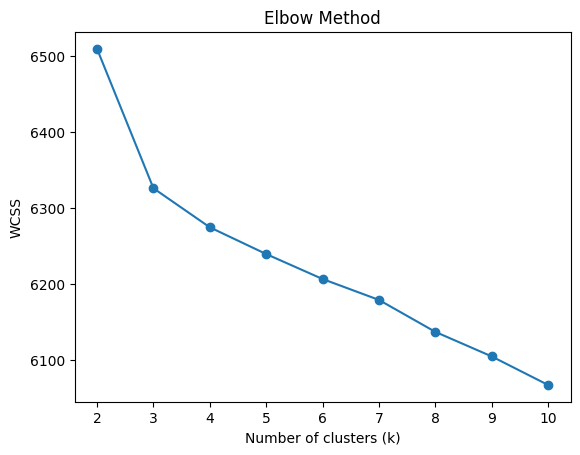

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(2, 11), wcss, marker='o')
plt.xticks(range(2,11))
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


In [ ]:
!pip install kneed
from kneed import KneeLocator

In [ ]:
knee = KneeLocator(range(2,11), wcss, curve='convex', direction='decreasing')

In [ ]:
kl = knee.elbow

In [ ]:
kl

np.int64(3)

In [ ]:
kmeans = KMeans(n_clusters = 3, init='k-means++',random_state=42)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [ ]:
df['cluster'] = kmeans.predict(X)

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X,kmeans.labels_)
score

np.float64(0.0629966206547789)

In [ ]:
def recommend(song_name, n=5):
    if song_name not in df['album'].values:
        print("Song not found.")
        return

    idx = df[df['album'] == song_name].index
    if len(idx) == 0:
        idx = df[df['artists'] == song_name].index
    idx = idx[0]
    cluster_label = df.loc[idx, 'cluster']
    similar_songs = df[df['cluster'] == cluster_label]
    similar_songs = similar_songs[similar_songs.index != idx].sort_values(by='popularity', ascending=False)
    return similar_songs.head(n)[['artists', 'album']]


In [ ]:
recommend('Dizzy up the Girl',n=5)

,artists,album
5540,"Dream Supplier, Baby Sleeps, Background White ...",Best White Noise For Sleeping Baby
3158,"The Weeknd, JENNIE, Lily-Rose Depp",The Idol Episode 4 (Music from the HBO Origina...
2797,Harry Styles,Harry's House
3213,ILLIT,SUPER REAL ME
4745,Benson Boone,Fireworks & Rollerblades
